# Regularization Techniques in Deep Learning

## Assignment Coverage
This notebook covers **Part 1 (a-d)** of the assignment:
- **L1 and L2 Regularization** - Weight penalty methods to prevent overfitting
- **Dropout** - Randomly dropping neurons during training
- **Early Stopping** - Halting training when validation loss stops improving
- **Monte Carlo Dropout** - Using dropout at inference for uncertainty estimation

Each technique is implemented in both **TensorFlow/Keras** and **PyTorch** with A/B comparisons showing regularized vs non-regularized models.

**Dataset**: Fashion MNIST (lightweight, suitable for demonstrating overfitting)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [2]:
# Load and preprocess Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train_flat = X_train.reshape(-1, 784).astype('float32')
X_test_flat = X_test.reshape(-1, 784).astype('float32')

# Use subset to demonstrate overfitting more clearly
X_train_small, y_train_small = X_train_flat[:5000], y_train[:5000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


---
## 1. L1 and L2 Regularization

**L1 (Lasso)**: Adds absolute weight values to loss, promotes sparsity  
**L2 (Ridge)**: Adds squared weight values to loss, prevents large weights

### TensorFlow Implementation

In [3]:
def build_tf_model(regularizer=None):
    """Build a simple MLP with optional regularization."""
    return keras.Sequential([
        keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizer, input_shape=(784,)),
        keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizer),
        keras.layers.Dense(10, activation='softmax')
    ])

In [4]:
# A/B Test: No regularization vs L1 vs L2
models_tf = {
    'No Reg': build_tf_model(None),
    'L1': build_tf_model(keras.regularizers.l1(0.001)),
    'L2': build_tf_model(keras.regularizers.l2(0.001)),
    'L1_L2': build_tf_model(keras.regularizers.l1_l2(l1=0.001, l2=0.001))
}

histories_tf = {}
for name, model in models_tf.items():
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    histories_tf[name] = model.fit(X_train_small, y_train_small, epochs=30,
                                    validation_data=(X_test_flat, y_test), verbose=0)
    print(f"{name}: Test Acc = {model.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


No Reg: Test Acc = 0.8291
L1: Test Acc = 0.7949
L2: Test Acc = 0.7968
L1_L2: Test Acc = 0.7872


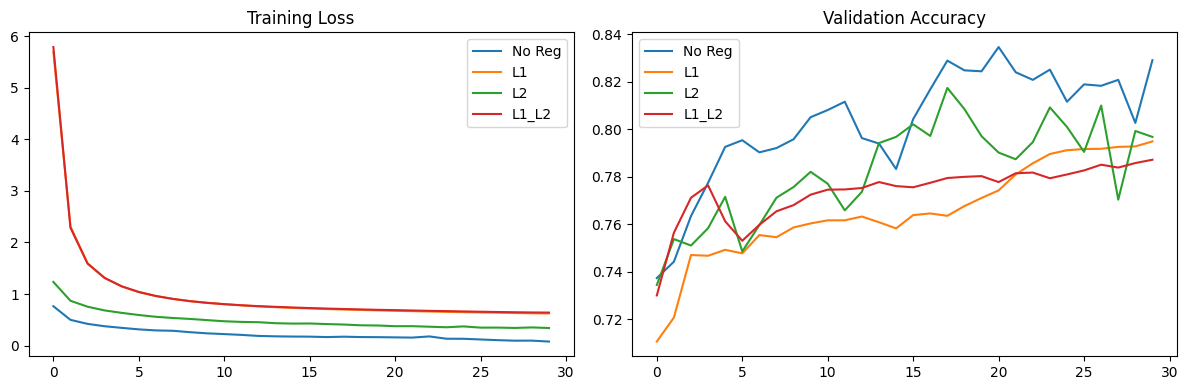

In [5]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in histories_tf.items():
    axes[0].plot(hist.history['loss'], label=name)
    axes[1].plot(hist.history['val_accuracy'], label=name)
axes[0].set_title('Training Loss'); axes[0].legend()
axes[1].set_title('Validation Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

### PyTorch Implementation

In [6]:
class MLPPyTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [7]:
# Prepare PyTorch dataloaders
train_ds = TensorDataset(torch.tensor(X_train_small), torch.tensor(y_train_small, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test_flat), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

In [8]:
def train_pytorch(model, train_loader, test_loader, epochs=30, l1_lambda=0, l2_lambda=0):
    """Training loop with optional L1/L2 regularization."""
    criterion = nn.CrossEntropyLoss()
    # L2 regularization via weight_decay parameter
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=l2_lambda)

    history = {'loss': [], 'val_acc': []}
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Manual L1 regularization
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation accuracy
        model.eval()
        correct = sum((model(X).argmax(1) == y).sum().item() for X, y in test_loader)
        val_acc = correct / len(test_ds)
        history['loss'].append(epoch_loss / len(train_loader))
        history['val_acc'].append(val_acc)

    return history, val_acc

In [9]:
# A/B Test in PyTorch
configs = {'No Reg': (0, 0), 'L1': (0.0001, 0), 'L2': (0, 0.001), 'L1_L2': (0.0001, 0.001)}
histories_pt = {}

for name, (l1, l2) in configs.items():
    model = MLPPyTorch()
    hist, acc = train_pytorch(model, train_loader, test_loader, l1_lambda=l1, l2_lambda=l2)
    histories_pt[name] = hist
    print(f"{name}: Test Acc = {acc:.4f}")

No Reg: Test Acc = 0.8390
L1: Test Acc = 0.8365
L2: Test Acc = 0.8272
L1_L2: Test Acc = 0.8175


---
## 2. Dropout

### TensorFlow Implementation

In [10]:
def build_tf_dropout_model(dropout_rate=0.0):
    return keras.Sequential([
        keras.layers.Dense(256, activation='relu', input_shape=(784,)),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(10, activation='softmax')
    ])

In [11]:
# A/B Test: Different dropout rates
dropout_rates = [0.0, 0.2, 0.5]
dropout_histories = {}

for rate in dropout_rates:
    model = build_tf_dropout_model(rate)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(X_train_small, y_train_small, epochs=30,
                     validation_data=(X_test_flat, y_test), verbose=0)
    dropout_histories[f'Dropout={rate}'] = hist
    print(f"Dropout={rate}: Test Acc = {model.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dropout=0.0: Test Acc = 0.8209
Dropout=0.2: Test Acc = 0.8378
Dropout=0.5: Test Acc = 0.8370


### PyTorch Implementation

In [12]:
class MLPDropout(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
for rate in [0.0, 0.2, 0.5]:
    model = MLPDropout(rate)
    _, acc = train_pytorch(model, train_loader, test_loader, epochs=30)
    print(f"PyTorch Dropout={rate}: Test Acc = {acc:.4f}")

PyTorch Dropout=0.0: Test Acc = 0.8313
PyTorch Dropout=0.2: Test Acc = 0.8457
PyTorch Dropout=0.5: Test Acc = 0.8397


---
## 3. Early Stopping

### TensorFlow Implementation

In [14]:
# Early stopping callback halts training when validation loss stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # Stop after 5 epochs without improvement
    restore_best_weights=True
)

model_es = build_tf_model()
model_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_es = model_es.fit(X_train_small, y_train_small, epochs=100,
                          validation_data=(X_test_flat, y_test),
                          callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch {len(history_es.history['loss'])}")
print(f"Test Accuracy: {model_es.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7328 - loss: 0.7539 - val_accuracy: 0.7283 - val_loss: 0.6842
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8248 - loss: 0.4942 - val_accuracy: 0.7626 - val_loss: 0.6205
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8512 - loss: 0.4154 - val_accuracy: 0.7732 - val_loss: 0.6064
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8696 - loss: 0.3666 - val_accuracy: 0.7641 - val_loss: 0.6477
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8762 - loss: 0.3388 - val_accuracy: 0.7864 - val_loss: 0.5767
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8854 - loss: 0.3106 - val_accuracy: 0.7989 - val_loss: 0.5700
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8918 - loss: 0.3020 - val_accuracy: 0.8055 - val_loss: 0.5592
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8948 - loss: 0.2777 - v

### PyTorch Implementation

In [15]:
class EarlyStopping:
    """Early stopping handler for PyTorch."""
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.best_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

In [16]:
model_pt = MLPPyTorch()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters())
early_stopper = EarlyStopping(patience=5)

for epoch in range(100):
    model_pt.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_pt(X_batch), y_batch)
        loss.backward()
        optimizer.step()

    # Compute validation loss
    model_pt.eval()
    val_loss = sum(criterion(model_pt(X), y).item() for X, y in test_loader) / len(test_loader)

    if early_stopper(val_loss, model_pt):
        print(f"Early stopping at epoch {epoch + 1}")
        model_pt.load_state_dict(early_stopper.best_weights)
        break

# Final accuracy
model_pt.eval()
correct = sum((model_pt(X).argmax(1) == y).sum().item() for X, y in test_loader)
print(f"Test Accuracy: {correct / len(test_ds):.4f}")

Early stopping at epoch 19
Test Accuracy: 0.8393


---
## 4. Monte Carlo Dropout

MC Dropout enables dropout during inference for uncertainty estimation. Multiple forward passes with dropout produce a distribution of predictions.

### TensorFlow Implementation

In [17]:
class MCDropoutLayer(keras.layers.Dropout):
    """Dropout layer that stays active during inference."""
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)  # Always apply dropout

In [18]:
mc_model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    MCDropoutLayer(0.5),
    keras.layers.Dense(128, activation='relu'),
    MCDropoutLayer(0.5),
    keras.layers.Dense(10, activation='softmax')
])

mc_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mc_model.fit(X_train_small, y_train_small, epochs=20, validation_split=0.1, verbose=0)

In [19]:
# MC Dropout inference: multiple forward passes for uncertainty
n_samples = 100
test_sample = X_test_flat[:10]

mc_predictions = np.array([mc_model(test_sample, training=True).numpy() for _ in range(n_samples)])

mean_pred = mc_predictions.mean(axis=0)
std_pred = mc_predictions.std(axis=0)

print("Prediction Uncertainty (std) for first 5 samples:")
for i in range(5):
    pred_class = mean_pred[i].argmax()
    confidence = mean_pred[i, pred_class]
    uncertainty = std_pred[i, pred_class]
    print(f"Sample {i}: Class={pred_class}, Confidence={confidence:.3f}, Uncertainty={uncertainty:.3f}")

Prediction Uncertainty (std) for first 5 samples:
Sample 0: Class=9, Confidence=0.807, Uncertainty=0.187
Sample 1: Class=2, Confidence=0.940, Uncertainty=0.105
Sample 2: Class=1, Confidence=1.000, Uncertainty=0.002
Sample 3: Class=1, Confidence=1.000, Uncertainty=0.000
Sample 4: Class=6, Confidence=0.628, Uncertainty=0.186


### PyTorch Implementation

In [20]:
class MCDropoutModel(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        return torch.softmax(self.fc3(x), dim=1)

    def mc_predict(self, x, n_samples=100):
        """Multiple forward passes with dropout enabled."""
        self.train()  # Keep dropout active
        predictions = torch.stack([self(x) for _ in range(n_samples)])
        return predictions.mean(0), predictions.std(0)

In [21]:
mc_model_pt = MCDropoutModel()
train_pytorch(mc_model_pt, train_loader, test_loader, epochs=20)

# MC inference
test_tensor = torch.tensor(X_test_flat[:10])
mean_pred, std_pred = mc_model_pt.mc_predict(test_tensor, n_samples=100)

print("\nPyTorch MC Dropout Predictions:")
for i in range(5):
    pred_class = mean_pred[i].argmax().item()
    print(f"Sample {i}: Class={pred_class}, Confidence={mean_pred[i, pred_class]:.3f}, Uncertainty={std_pred[i, pred_class]:.3f}")


PyTorch MC Dropout Predictions:
Sample 0: Class=9, Confidence=0.694, Uncertainty=0.327
Sample 1: Class=2, Confidence=1.000, Uncertainty=0.002
Sample 2: Class=1, Confidence=1.000, Uncertainty=0.003
Sample 3: Class=1, Confidence=1.000, Uncertainty=0.000
Sample 4: Class=6, Confidence=0.980, Uncertainty=0.094


---
## Summary

| Technique | Purpose | When to Use |
|-----------|---------|-------------|
| **L1 Regularization** | Feature selection, sparse weights | High-dimensional data, need interpretability |
| **L2 Regularization** | Prevent large weights | General overfitting prevention |
| **Dropout** | Reduce co-adaptation | Deep networks, limited data |
| **Early Stopping** | Prevent overtraining | Always recommended as baseline |
| **MC Dropout** | Uncertainty estimation | Need confidence intervals, safety-critical applications |